Problem 1 — Academic Impact
"Does AI tool usage actually improve student GPA, or does it vary by how they use it?"

This investigates whether hours spent on GenAI, type of use case (e.g. writing vs. coding help), and skill level (prompt engineering) meaningfully predict GPA change. A senior analyst would measure this with segmentation + correlation + regression.







Before touching any data, a senior analyst breaks the problem into specific, answerable sub-questions:

Do students have a GPA improvement after the semester? (Post - Pre)

Does more AI usage (Weekly_GenAI_Hours) correlate with higher GPA change?

Does how they use AI (Primary_Use_Case) change the outcome?

Does their skill level (Prompt_Engineering_Skill) matter?

Does more AI usage come at the cost of skill retention?

These 5 sub-questions become your analysis checklist. You don't move to visualization until you can answer each one.

STEP 1 - CLEAN THE DATA


In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('ai_student_impact_dataset.csv')
df


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [18]:
cols = ['Pre_Semester_GPA', 'Post_Semester_GPA', 'Weekly_GenAI_Hours', 
        'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Skill_Retention_Score',
        'Major_Category', 'Year_of_Study']
df[cols].isnull().sum()

Pre_Semester_GPA            0
Post_Semester_GPA           0
Weekly_GenAI_Hours          0
Primary_Use_Case            0
Prompt_Engineering_Skill    0
Skill_Retention_Score       0
Major_Category              0
Year_of_Study               0
dtype: int64

In [19]:
df['Weekly_GenAI_Hours'].describe()

count    50000.000000
mean         8.427752
std          8.269490
min          0.000000
25%          2.390000
50%          5.800000
75%         11.720000
max         40.000000
Name: Weekly_GenAI_Hours, dtype: float64

In [ ]:
df['Prompt_Engineering_Skill'].value_counts()


Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

In [21]:
df['Primary_Use_Case'].value_counts()

Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

In [29]:
df['Major_Category'].value_counts()

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

In [22]:
df['Year_of_Study'].value_counts()

Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64

STEP 2  - GPA CHANGE 

In [23]:
df['GPA_Change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']
df['GPA_Change'].describe()

count    50000.000000
mean         0.203197
std          0.187192
min         -0.924000
25%          0.087000
50%          0.204000
75%          0.325000
max          1.008000
Name: GPA_Change, dtype: float64

In [24]:
print('Improved', (df['GPA_Change'] > 0).sum())
print('Declined', (df['GPA_Change'] < 0).sum())
print('Unchanged', (df['GPA_Change'] == 0).sum())

Improved 43759
Declined 6192
Unchanged 49


STEP 3 - EDA

In [25]:
df.groupby('Primary_Use_Case')['GPA_Change'].mean().sort_values(ascending = False)


Primary_Use_Case
Debugging/Troubleshooting    0.249128
Copywriting/Drafting         0.200426
Ideation                     0.199942
Summarizing_Reading          0.196886
Direct_Answer_Generation     0.133473
Name: GPA_Change, dtype: float64

In [26]:
df.groupby("Prompt_Engineering_Skill")["GPA_Change"].mean().sort_values(ascending=False)

Prompt_Engineering_Skill
Advanced        0.248096
Intermediate    0.186924
Beginner        0.185244
Name: GPA_Change, dtype: float64

In [27]:
df["AI_Usage_Group"] = pd.cut(df['Weekly_GenAI_Hours'],
    bins = [0, 2, 5, 10, 20, 40],
    labels = ['Very Low (0-2h)', 'Low (2-5h)', 'Medium (5-10h)', 'High (10-20h)', 'Very High (20-40h)'])

df.groupby('AI_Usage_Group', observed = True)['GPA_Change'].mean().sort_values(ascending=False)



AI_Usage_Group
Medium (5-10h)        0.227248
High (10-20h)         0.216362
Low (2-5h)            0.200971
Very Low (0-2h)       0.187556
Very High (20-40h)    0.156227
Name: GPA_Change, dtype: float64

ANOVA

In [28]:
from scipy import stats

groups = [df[df["Primary_Use_Case"] == uc]['GPA_Change']
          for uc in df["Primary_Use_Case"].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print("F-Statistic:", round(f_stat, 4))
print("P-value:", round(p_value, 6))





F-Statistic: 422.6687
P-value: 0.0


In [29]:
f2, p2 = stats.f_oneway(
    df[df['Prompt_Engineering_Skill'] == 'Beginner']['GPA_Change'],
    df[df['Prompt_Engineering_Skill'] == 'Intermediate'] ['GPA_Change'],
    df[df['Prompt_Engineering_Skill'] == 'Advanced']['GPA_Change']
    
)

print("F-statistic:", round(f2,4))
print("P-value:", round(p2, 6))

F-statistic: 561.4705
P-value: 0.0


POST HOC

In [30]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey_usecase = pairwise_tukeyhsd(
    endog = df['GPA_Change'],
    groups = df['Primary_Use_Case'],
    alpha = 0.05
)

print(tukey_usecase)


                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                    
          group1                    group2          meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------------------------
     Copywriting/Drafting Debugging/Troubleshooting   0.0487    0.0  0.0423  0.0551   True
     Copywriting/Drafting  Direct_Answer_Generation   -0.067    0.0 -0.0747 -0.0592   True
     Copywriting/Drafting                  Ideation  -0.0005 0.9997 -0.0072  0.0062  False
     Copywriting/Drafting       Summarizing_Reading  -0.0035 0.6518 -0.0106  0.0035  False
Debugging/Troubleshooting  Direct_Answer_Generation  -0.1157    0.0 -0.1234 -0.1079   True
Debugging/Troubleshooting                  Ideation  -0.0492    0.0 -0.0558 -0.0425   True
Debugging/Troubleshooting       Summarizing_Reading  -0.0522    0.0 -0.0593 -0.0452   True
 Direct_Answer_Generation                  Ideation   0.0665    0.0  0.0585  0.0744   True

In [31]:
tukey_skills = pairwise_tukeyhsd(
    endog = df['GPA_Change'],
    groups = df['Prompt_Engineering_Skill'],
    alpha = 0.05
)

print(tukey_skills)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1     group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------
Advanced     Beginner  -0.0629    0.0 -0.0677  -0.058   True
Advanced Intermediate  -0.0612    0.0 -0.0661 -0.0562   True
Beginner Intermediate   0.0017 0.6635 -0.0029  0.0062  False
------------------------------------------------------------


In [34]:
print(df.groupby('Primary_Use_Case')['GPA_Change'].mean().sort_values(ascending=False))
print(df.groupby('Prompt_Engineering_Skill')['GPA_Change'].mean().sort_values(ascending=False))

Primary_Use_Case
Debugging/Troubleshooting    0.249128
Copywriting/Drafting         0.200426
Ideation                     0.199942
Summarizing_Reading          0.196886
Direct_Answer_Generation     0.133473
Name: GPA_Change, dtype: float64
Prompt_Engineering_Skill
Advanced        0.248096
Intermediate    0.186924
Beginner        0.185244
Name: GPA_Change, dtype: float64


STEP 4 - MULTIPLE LINEAR REGRESSION

In [49]:
import statsmodels.formula.api as smf

model = smf.ols(
    formula = 'GPA_Change ~ Weekly_GenAI_Hours + Traditional_Study_Hours + C(Primary_Use_Case) + C(Prompt_Engineering_Skill) + C(Year_of_Study) + C(Major_Category)',
    data = df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             GPA_Change   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     1067.
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:02:25   Log-Likelihood:                 20180.
No. Observations:               50000   AIC:                        -4.033e+04
Df Residuals:                   49983   BIC:                        -4.018e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

STEP 5 - CORRELATION ANALYSIS: AI USAGE HOURS & SKILL RETENTION

Correlation: -0.1181


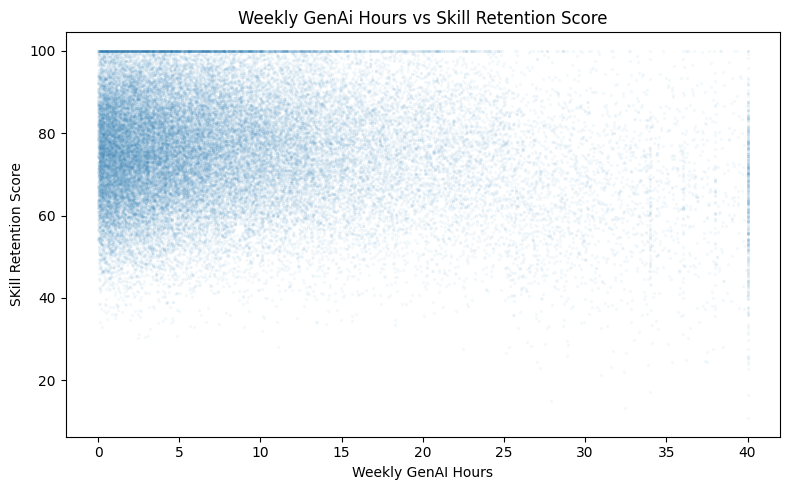

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df['Weekly_GenAI_Hours'].corr(df['Skill_Retention_Score'])
print(f"Correlation: {round(correlation, 4)}")

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Weekly_GenAI_Hours', y='Skill_Retention_Score', alpha=0.05, s=5)
plt.title('Weekly GenAi Hours vs Skill Retention Score')
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('SKill Retention Score')
plt.tight_layout()
plt.show()

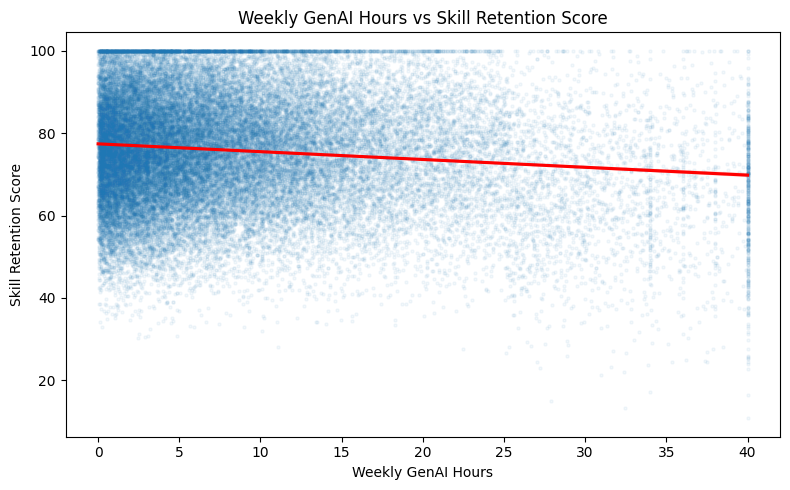

In [14]:
plt.figure(figsize=(8,5))
sns.regplot(
    data=df,
    x='Weekly_GenAI_Hours',
    y='Skill_Retention_Score',
    scatter_kws={'alpha': 0.05, 's': 5},
    line_kws={'color': 'red'}
)
plt.title('Weekly GenAI Hours vs Skill Retention Score')
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('Skill Retention Score')
plt.tight_layout()
plt.show()

The Final Summary

How a student uses AI matters far more than how much they use it. Weekly GenAI hours alone is not a significant predictor of GPA improvement.
 What drives outcomes is the type of use — Debugging/Troubleshooting leads to the best results (+0.049) while Direct_Answer_Generation leads to the worst (-0.067). Prompt engineering skill matters only at the Advanced level. Year of study is a strong predictor — more advanced students benefit more from AI, with Graduate students showing the highest improvement (+0.120). Traditional study hours remain the strongest continuous predictor. Major category has no significant effect.